Code for CAISO data downloading (e.g. LMP, AS) from OASIS
https://opensource.gridstatus.io/en/latest/autoapi/gridstatus/caiso/index.html#gridstatus.caiso.CAISO.get_as_prices"

Author Yizhan Gu
Email: yig031@ucsd.edu

In [2]:

import numpy as np
import calendar
from datetime import datetime
from datetime import timedelta
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

# import plotly.express as px
import matplotlib
import matplotlib.dates as mdates
import warnings
import os
import sys
warnings.filterwarnings("ignore")
from caiso import CAISO
iso = CAISO()

year = 2025
markets = ["DAM", 'RTM']

In [ ]:



for market in markets:
    print(f"Downloading AS prices for {market} in {year}...")
    
    # Download Ancillary service price

    if market == 'DAM':
        df = iso.get_as_prices(start=f"Jun 1, {year}", end=f"Aug 1, {year}", market=market)  # whole range
    elif market == 'RTM':
        df = iso.get_interval_as_prices(start=f"Jun 1, {year}", end=f"Aug 1, {year}", market=market)  # whole range
        
    output_dir = f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}'
    os.makedirs(output_dir, exist_ok=True)
    df.to_csv(f'{output_dir}/AS_price_{year}.csv', index=False)


  0%|          | 0/61 [00:00<?, ?it/s]2025-08-04 02:50:21 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_AS', 'version': 12}, 'params': {'market_run_id': ['DAM', 'HASP'], 'anc_type': ['ALL', 'NR', 'RD', 'RMD', 'RMU', 'RU', 'SR'], 'anc_region': ['ALL', 'AS_CAISO', 'AS_SP26_EXP', 'AS_SP26', 'AS_CAISO_EXP', 'AS_NP26_EXP', 'AS_NP26']}}
2025-08-04 02:50:21 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_AS&version=12&market_run_id=DAM&anc_type=ALL&anc_region=ALL&startdatetime=20250601T07:00-0000&enddatetime=20250602T07:00-0000
2025-08-04 02:50:22 - DEBUG - Found 1 files: ['20250601_20250601_PRC_AS_DAM_v12.csv']
2025-08-04 02:50:22 - DEBUG - Parsing file: 20250601_20250601_PRC_AS_DAM_v12.csv
  2%|▏         | 1/61 [00:04<04:49,  4.82s/it]2025-08-04 02:50:26 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_AS', 'version': 12}, 'params': {'market_run_id': [

  0%|          | 0/1464 [00:00<?, ?it/s]2025-08-04 02:58:03 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_AS', 'version': 1}, 'params': {'market_run_id': ['RTM'], 'anc_type': ['ALL', 'NR', 'RD', 'RMD', 'RMU', 'RU', 'SR'], 'anc_region': ['ALL', 'AS_CAISO', 'AS_SP26_EXP', 'AS_SP26', 'AS_CAISO_EXP', 'AS_NP26_EXP', 'AS_NP26']}}
2025-08-04 02:58:03 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_AS&version=1&market_run_id=RTM&anc_type=ALL&anc_region=ALL&startdatetime=20250601T07:00-0000&enddatetime=20250601T08:00-0000
2025-08-04 02:58:04 - DEBUG - Found 1 files: ['20250601_20250601_PRC_INTVL_AS_RTM_01_v1.csv']
2025-08-04 02:58:04 - DEBUG - Parsing file: 20250601_20250601_PRC_INTVL_AS_RTM_01_v1.csv
  0%|          | 1/1464 [00:10<4:22:19, 10.76s/it]2025-08-04 02:58:14 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_AS', 'version': 1}, 

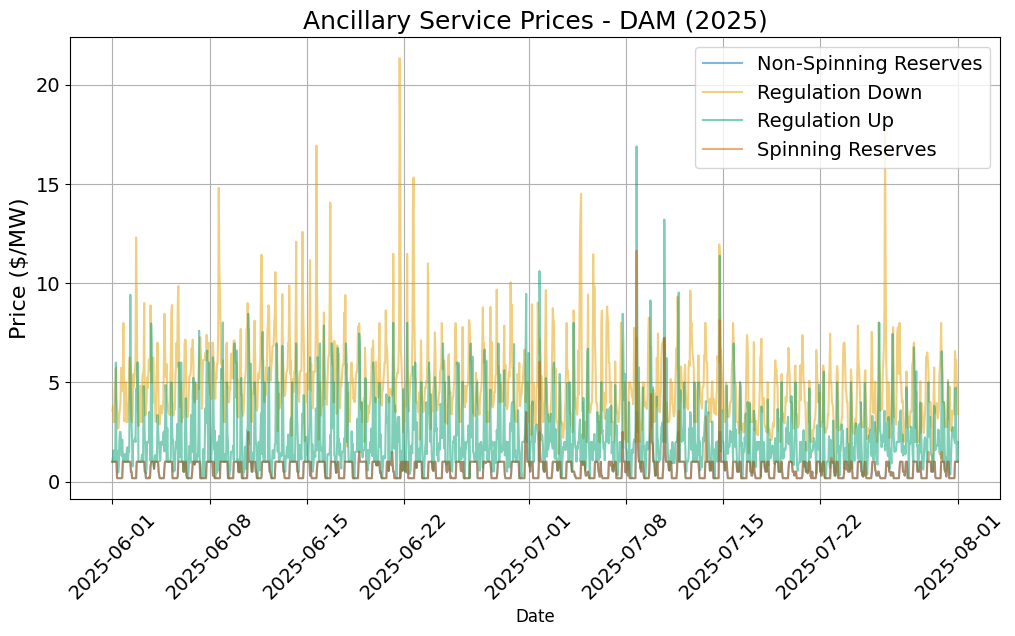

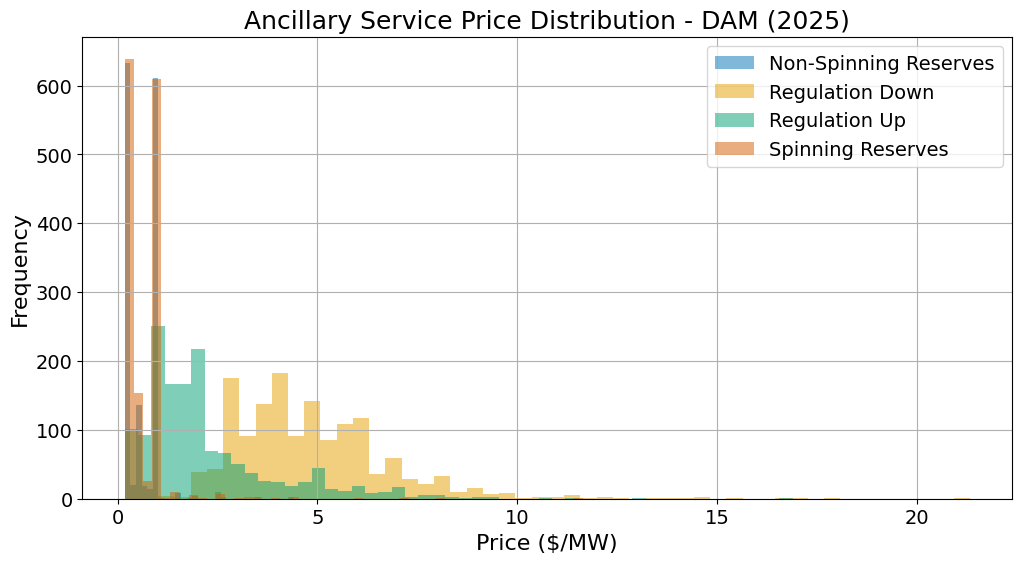

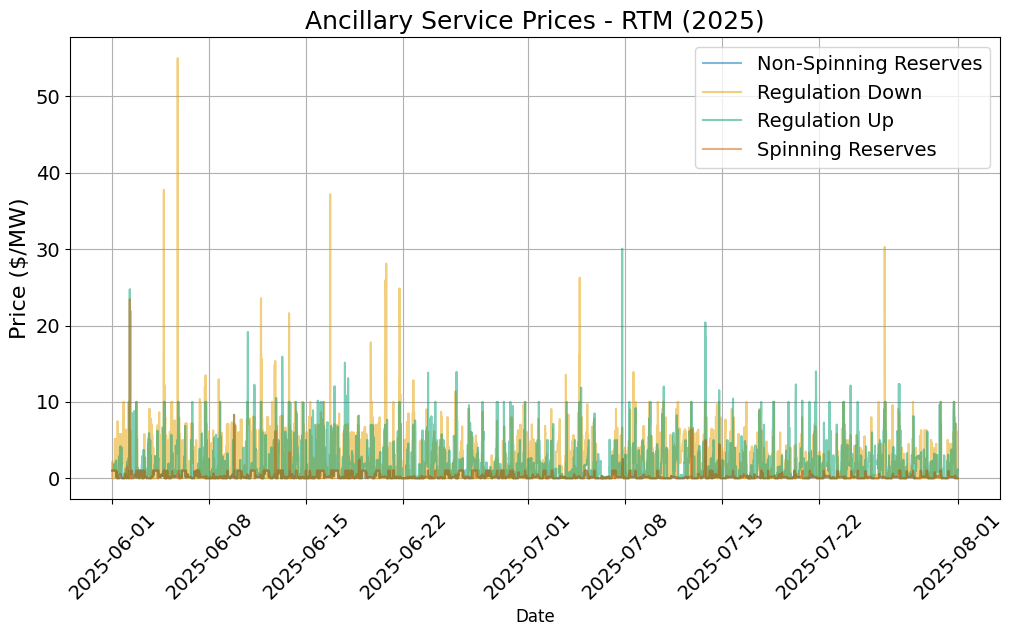

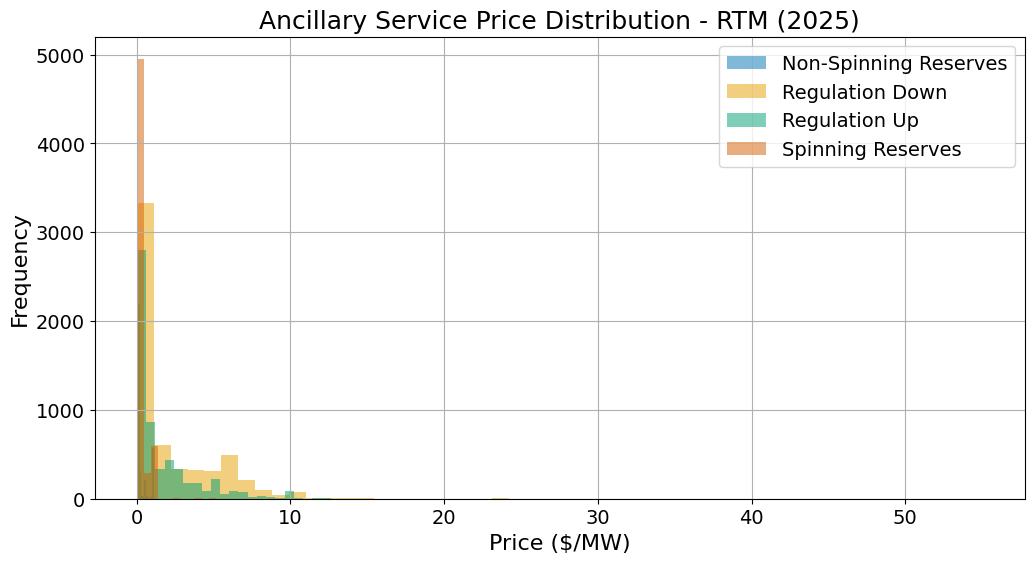

In [3]:
# Read and process the downloaded data
for market in markets:


    df_all = pd.read_csv(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}.csv')
    df = df_all[(df_all["Region"] == "AS_CAISO_EXP") & (df_all["Market"] == market)]
    # df = df_all[(df_all["Region"] == "AS_CAISO") & (df_all["Market"] == market)]


    df['Time'] = pd.to_datetime(df['Time'], utc=True)
    # NOTE: time from utc to local timezone
    df['datetime'] = df['Time'].dt.tz_convert('America/Los_Angeles')
    df.drop(columns=['Time', 'Interval Start', 'Interval End'], inplace=True)
    df = df.groupby(['datetime']).agg({
        'Non-Spinning Reserves': 'sum',
        'Regulation Down': 'sum',
        'Regulation Mileage Down': 'sum',
        'Regulation Mileage Up': 'sum',
        'Regulation Up': 'sum',
        'Spinning Reserves': 'sum'}).reset_index()
    df.rename(columns={
        'Non-Spinning Reserves': 'NonSpin',
        'Regulation Down': 'RegDown',
        'Regulation Mileage Down': 'RegDownMileage',
        'Regulation Mileage Up': 'RegUpMileage',
        'Regulation Up': 'RegUp',
        'Spinning Reserves': 'Spin'
    }, inplace=True)

    df.to_csv('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{}/AS_price_{}_clear.csv'.format(market, year), index=False)
    
    # Use a colorblind-friendly palette
    colors = {
        'NonSpin': '#0072B2',    # Blue
        'RegDown': '#E69F00',    # Orange
        'RegUp': '#009E73',      # Green
        'Spin': '#D55E00',       # Vermillion
    }

    # Update plot colors
    plt.figure(figsize=(12, 6))
    plt.plot(df['datetime'], df['NonSpin'], label='Non-Spinning Reserves', color=colors['NonSpin'], alpha=0.5)
    plt.plot(df['datetime'], df['RegDown'], label='Regulation Down', color=colors['RegDown'], alpha=0.5)
    plt.plot(df['datetime'], df['RegUp'], label='Regulation Up', color=colors['RegUp'], alpha=0.5)
    plt.plot(df['datetime'], df['Spin'], label='Spinning Reserves', color=colors['Spin'], alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($/MW)', fontsize=16)
    plt.title(f'Ancillary Service Prices - {market} ({year})', fontsize=18)
    plt.legend(fontsize=14)
    plt.grid()
    plt.xticks(fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(fontsize=14)
    # plt.ylim(0, 20)
    plt.savefig(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_plot.png')
    plt.show()
    plt.close()

    # Histogram with colorblind-friendly palette
    plt.figure(figsize=(12, 6))
    plt.hist(df['NonSpin'], bins=50, alpha=0.5, label='Non-Spinning Reserves', color=colors['NonSpin'])
    plt.hist(df['RegDown'], bins=50, alpha=0.5, label='Regulation Down', color=colors['RegDown'])
    plt.hist(df['RegUp'], bins=50, alpha=0.5, label='Regulation Up', color=colors['RegUp'])
    plt.hist(df['Spin'], bins=50, alpha=0.5, label='Spinning Reserves', color=colors['Spin'])
    plt.xlabel('Price ($/MW)', fontsize=16)
    plt.ylabel('Frequency', fontsize=16)
    plt.title(f'Ancillary Service Price Distribution - {market} ({year})', fontsize=18)
    plt.legend(fontsize=14)
    # plt.xlim(0, 15)
    plt.grid()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_histogram.png')
    plt.show()
    plt.close()
